In [64]:
import os
import numpy as np
import h5py
from scipy import signal
from scipy.stats import pearsonr
import seaborn as sns
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import string

# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = os.path.join(parent_dir, 'dfs')


In [65]:
# Load device, cshq, and sleep diary data file:
df_3nights = pd.read_csv(os.path.join(data_path, 'merged_3nights.csv'))
df_cshq = pd.read_csv(os.path.join(data_path, 'df_cshq_clean.csv'))

# Load subject demographics:
df_demographics = pd.read_csv(os.path.join(data_path, 'SSP_participants.csv'))

print(f"Number of recordings in df3_nights: {len(df_3nights)}")
print(f"Number of subjects in df_cshq: {len(df_cshq)}")
print(f"Number of subjects in df_demographics: {len(df_demographics)}")

Number of recordings in df3_nights: 1151
Number of subjects in df_cshq: 200
Number of subjects in df_demographics: 200


### Preprocess the 3_nights data

In [67]:
# Compute the average per subject of selected sleep measures:

df_3nights_bysub = df_3nights[['SPID', 'SOL_dreem',
                               'TST_dreem', 'TST_embrace', 'TST_withings', 'TST_diary', 
                               'WASO_dreem', 'WASO_embrace', 'WASO_withings', 'WASO_diary']].groupby('SPID').mean()

# Replace SOL_dreem values larger than 120 with Nan:
df_3nights_bysub['SOL_dreem'] = df_3nights_bysub['SOL_dreem'].apply(lambda x: np.nan if x>120 else x)

print(len(df_3nights_bysub))
print(f"Number of nights after filtering SOL periods longer than 2h: {df_3nights_bysub['SOL_dreem'].notna().sum()}")

136
Number of nights after filtering SOL periods longer than 2h: 135


In [69]:
# Merge demographic details and cshq into the dataframe:
df_3nights_demog = df_3nights_bysub.merge(df_demographics[['SPID', 'family_SPID', 'sex', 'asd', 
                                                           'age_months', 'age_years']], on='SPID', how='inner')

# Merge cshq data:
df_3nights_demog = df_3nights_demog.merge(df_cshq[['SPID', 'TST', 'WASO']], on='SPID', how='inner')

# Rename TST and WASO columns to TST_cshq and WASO_cshq:
df_3nights_demog = df_3nights_demog.rename(columns={'TST': 'TST_cshq', 'WASO': 'WASO_cshq'})


print(f"Number of subjects in df_3nights_demog: {len(df_3nights_demog)}")

Number of subjects in df_3nights_demog: 136


In [70]:
# Count number of ASD and Sibs:
asd_count = df_3nights_demog['asd'].sum()
sib_count = len(df_3nights_demog) - asd_count

# Compute the mean SOL_dreem for ASD and Sibs:
asd_SOL = df_3nights_demog[df_3nights_demog['asd']==1]['SOL_dreem'].mean()
sib_SOL = df_3nights_demog[df_3nights_demog['asd']==0]['SOL_dreem'].mean()

print(f"Number of ASD subjects: {asd_count}")
print(f"Number of Sibs subjects: {sib_count}")
print(f"Mean SOL_dreem for ASD subjects: {asd_SOL}")
print(f"Mean SOL_dreem for Sibs subjects: {sib_SOL}")

Number of ASD subjects: 69
Number of Sibs subjects: 67
Mean SOL_dreem for ASD subjects: 36.54594688118127
Mean SOL_dreem for Sibs subjects: 28.82235247422414


### Plot Sleep measures comparison across groups 

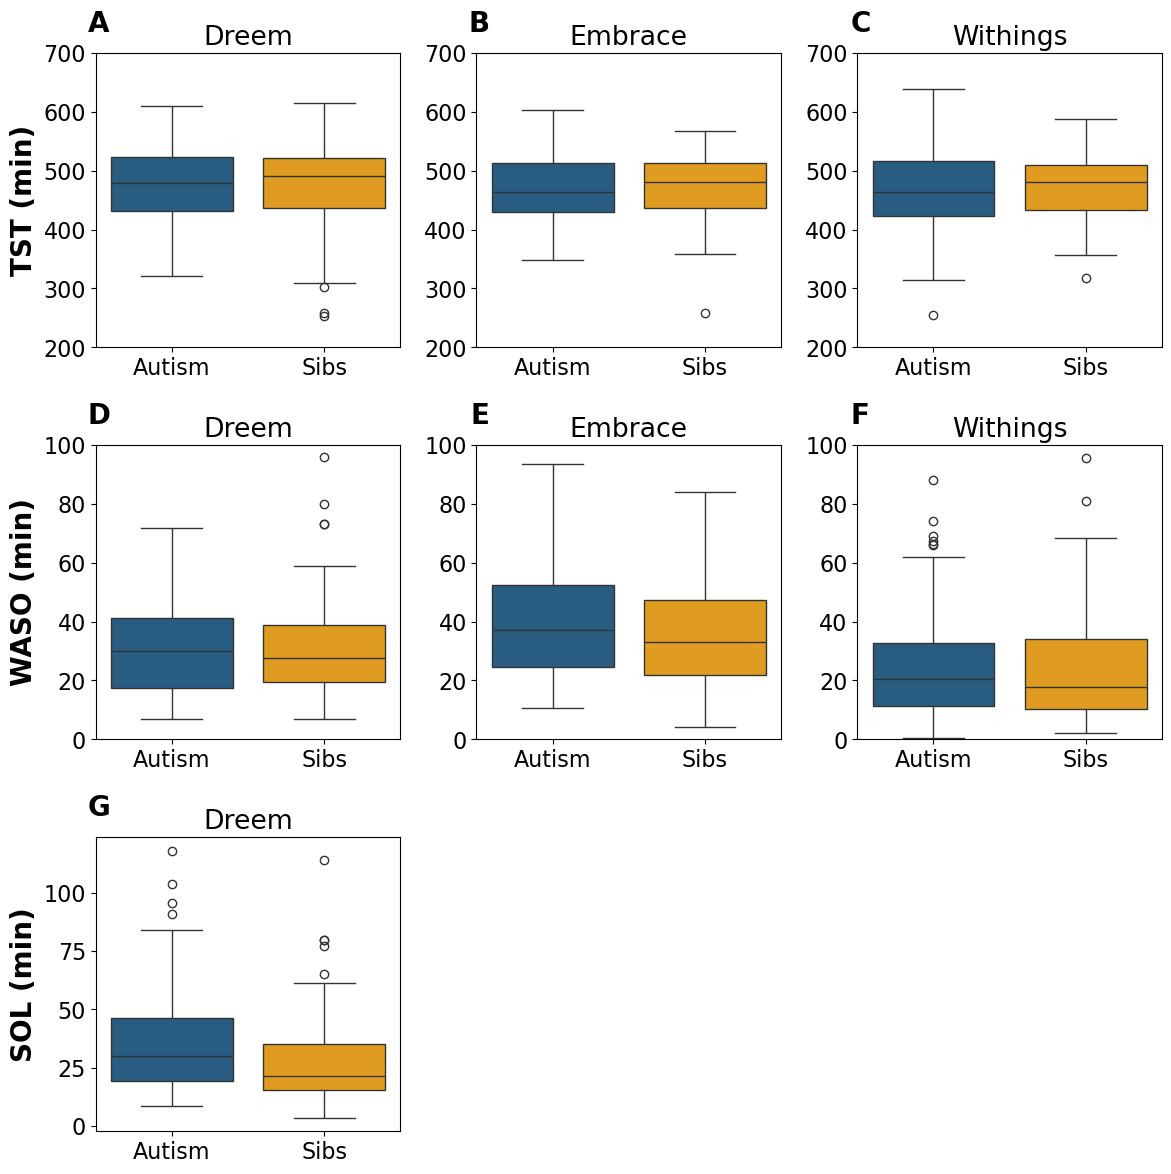

In [80]:
# List of SO FA TST and WASO columns
tst_columns = ['TST_dreem', 'TST_embrace', 'TST_withings']
waso_columns = ['WASO_dreem', 'WASO_embrace', 'WASO_withings']
sol_columns = ['SOL_dreem']

# Combine all columns to plot
columns_to_plot = tst_columns + waso_columns + sol_columns

# Organize the data by group:
df_3nights_demog['Group'] = df_3nights_demog.apply(lambda row: 'Autism' if row['asd'] else 'Sibs', axis=1)

# Order in which to plot the groups:
group_order = ['Autism', 'Sibs']

# Create a figure with 9 subplots (3 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharey=False)

# Define a color palette for the groups
hue_colors = {'Autism': '#19609080', 'Sibs': '#FFA500'}

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Set global font size for the plot
plt.rcParams.update({'font.size': 16})

# Loop through the columns and create boxplots
for i, column in enumerate(columns_to_plot):
    ax = axes[i]
    sns.boxplot(data=df_3nights_demog, x='Group', y=column, ax=ax, order=group_order, hue='Group', dodge=False, palette=hue_colors)
    # Isolate the metric name from the column name:
    metric = column.split('_')[0].upper()
    if metric == 'TST':
        ax.set_ylim(200, 700)
    elif metric == 'WASO':
        ax.set_ylim(0, 100)

    # Isolate the metric name and device name from the column name
    metric, device = column.split('_')[0].upper(), column.split('_')[1].capitalize()

    ax.set_title(device)

    # Add capital letters in the top left corner of each panel
    panel_label = string.ascii_uppercase[i]  # Get the corresponding letter (A, B, C, etc.)
    ax.text(0.01, 1.1, panel_label, transform=ax.transAxes, fontsize=20, fontweight='bold', va='center', ha='center')

    ax.set_xlabel('')
    ax.set_ylabel('')

    # Enlarge x and y tick markers
    ax.tick_params(axis='both', which='major', labelsize=16)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a title to each row:
axes[0].set_ylabel('TST (min)', fontsize=20, fontweight='bold')
axes[3].set_ylabel('WASO (min)', fontsize=20, fontweight='bold')
axes[6].set_ylabel('SOL (min)', fontsize=20, fontweight='bold')

# Adjust layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()

In [85]:
# Differences in WASO across groups:
print("Difference in mean WASO_dreem between ASD and Sibs groups:")
print(df_3nights_demog[df_3nights_demog['asd']==1]['WASO_dreem'].mean() - df_3nights_demog[df_3nights_demog['asd']==0]['WASO_dreem'].mean())

print("Difference in mean WASO_embrace between ASD and Sibs groups:")
print(df_3nights_demog[df_3nights_demog['asd']==1]['WASO_embrace'].mean() - df_3nights_demog[df_3nights_demog['asd']==0]['WASO_embrace'].mean())

print("Difference in mean WASO_withings between ASD and Sibs groups:")
print(df_3nights_demog[df_3nights_demog['asd']==1]['WASO_withings'].mean() - df_3nights_demog[df_3nights_demog['asd']==0]['WASO_withings'].mean())

Difference in mean WASO_dreem between ASD and Sibs groups:
-0.8295551636636276
Difference in mean WASO_embrace between ASD and Sibs groups:
2.9432822493289663
Difference in mean WASO_withings between ASD and Sibs groups:
1.723975337846042


### Preform a mixed model analysis:

In [86]:
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# List of sleep measures to analyze
sleep_measures = ['TST_dreem', 'TST_embrace', 'TST_withings', 
                  'WASO_dreem', 'WASO_embrace', 'WASO_withings', 'SOL_dreem']

# Initialize a list to store results
all_results = []

# Add underscore to all column names with spaces:
df_3nights_demog.columns = df_3nights_demog.columns.str.replace(' ', '_')

# Preprocessing: Ensure no missing data for required variables
df_3nights_demog = df_3nights_demog.dropna(subset=sleep_measures + ['asd','sex', 'age_months', 'family_SPID'])

# Iterate through each sleep measure
for measure in sleep_measures:
    print(f"Analyzing {measure}")
    
    # Check if the measure exists in the DataFrame
    if measure not in df_3nights_demog.columns:
        print(f"  Warning: {measure} not found in df_3nights_demog, skipping...")
        continue

    # Define the formula
    formula = f"{measure} ~ asd + sex + age_months"
    
    try:
        # Fit the mixed-effects model
        model = smf.mixedlm(formula, df_3nights_demog, groups=df_3nights_demog["family_SPID"])
        result = model.fit()
        
        # Extract variance components
        random_effects_variance = result.cov_re.iloc[0, 0]  # Between-group variance
        residual_variance = result.scale  # Within-group (residual) variance
        
        # Calculate the intraclass correlation coefficient (ICC)
        icc = random_effects_variance / (random_effects_variance + residual_variance)
        
        # Extract fixed-effect estimates and p-values
        asd_effect = result.params.get('asd[T.True]', float('nan'))
        asd_pvalue = result.pvalues.get('asd[T.True]', float('nan'))
        sex_effect = result.params.get('sex[T.Male]', float('nan'))
        sex_pvalue = result.pvalues.get('sex[T.Male]', float('nan'))
        age_effect = result.params.get('age_months', float('nan'))
        age_pvalue = result.pvalues.get('age_months', float('nan'))
        
        # Append the results
        all_results.append({
            "Measure": measure,
            "Between-Pair Variance": random_effects_variance,
            "Within-Pair Variance": residual_variance,
            "ICC": icc,
            "ASD Effect (Beta)": asd_effect,
            "ASD Effect p-value": asd_pvalue,
            "Sex Effect (Beta)": sex_effect,
            "Sex Effect p-value": sex_pvalue,
            "Age Effect (Beta)": age_effect,
            "Age Effect p-value": age_pvalue
        })
    
    except Exception as e:
        print(f"  Error analyzing {measure}: {e}")

# Convert all results to a DataFrame for better visualization
results_df = pd.DataFrame(all_results)

# Display the results
print("\nSummary of Mixed Model Analysis:")
print(results_df)

# # Save results to a CSV file (optional)
# results_df.to_csv("mixed_model_results_3nights.csv", index=False)


Analyzing TST_dreem
Analyzing TST_embrace
Analyzing TST_withings
Analyzing WASO_dreem
Analyzing WASO_embrace
Analyzing WASO_withings
Analyzing SOL_dreem

Summary of Mixed Model Analysis:
         Measure  Between-Pair Variance  Within-Pair Variance           ICC  \
0      TST_dreem            2591.302269           1937.666388  5.721617e-01   
1    TST_embrace            2064.395858           1354.244439  6.038646e-01   
2   TST_withings            2045.055606           1912.944473  5.166891e-01   
3     WASO_dreem              87.420820            168.290170  3.418735e-01   
4   WASO_embrace             114.349211            363.797184  2.391510e-01   
5  WASO_withings               0.000002            404.190327  4.495869e-09   
6      SOL_dreem             174.363870            333.519964  3.433145e-01   

   ASD Effect (Beta)  ASD Effect p-value  Sex Effect (Beta)  \
0           8.153461            0.363596         -17.668398   
1           8.999254            0.230467         -29.3